# Dyna-Q vs SARSA: Head-to-Head Comparison

This notebook provides a rigorous comparative analysis of **Dyna-Q** (model-based) and **SARSA** (model-free) reinforcement learning agents on Micromouse maze navigation.

## Evaluation Framework
- **Learning Efficiency**: Episodes and steps to convergence
- **Policy Quality**: Path optimality, success rate, reward accumulation
- **Exploration Behavior**: State visitation patterns, coverage
- **Statistical Significance**: t-tests and Mann-Whitney U tests
- **Visual Analysis**: Side-by-side mazes, heatmaps, Q-value maps, radar charts

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.dpi'] = 100

from mazemind.envs.maze_parser import parse_maze_file, list_maze_files, load_random_maze
from mazemind.envs.micromouse_env import MicromouseEnv
from mazemind.agents.dyna_q import DynaQAgent
from mazemind.agents.sarsa import SarsaAgent
from mazemind.training.orchestrator import train_with_snapshots, extract_optimal_path
from mazemind.utils.metrics import ComparisonResult
from mazemind.visualization.maze_renderer import render_maze, render_maze_comparison
from mazemind.visualization.heatmap import render_heatmap, render_heatmap_comparison, render_q_value_map
from mazemind.visualization.metrics_plotter import (
    plot_comparison_learning_curves,
    plot_comparison_success_rates,
    plot_convergence_bar_chart,
    plot_epsilon_decay,
    plot_q_value_distribution,
    plot_radar_comparison,
    plot_step_distribution,
)
from scipy import stats

print('All imports successful.')

All imports successful.


## 1. Load Maze Environment

Maze: 13ye (16x16)
Start: (0, 0) -> Goals: {(8, 7), (8, 8), (7, 7), (7, 8)}


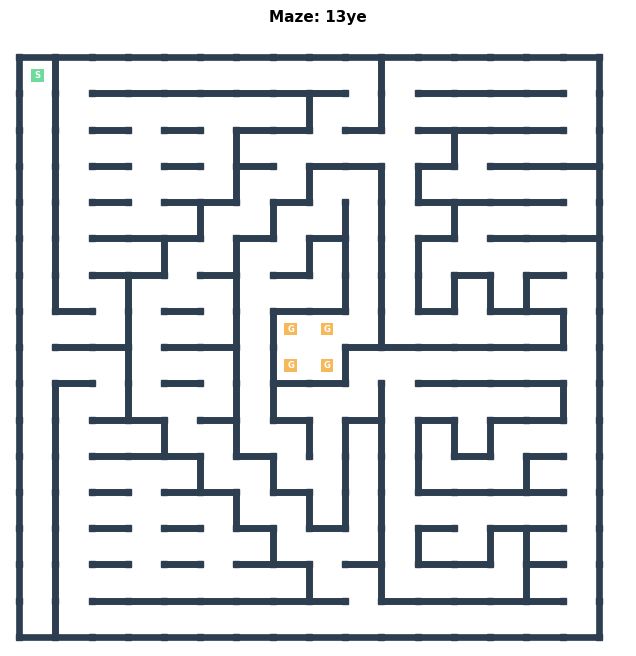

In [2]:
maze_dir = os.path.join('data', 'mazes', 'classic')

files = list_maze_files(maze_dir)
if len(files) < 3:
    from mazemind.envs.maze_parser import download_mazes
    download_mazes(maze_dir)
    files = list_maze_files(maze_dir)

maze = load_random_maze(maze_dir)
print(f'Maze: {maze.name} ({maze.size}x{maze.size})')
print(f'Start: {maze.start} -> Goals: {maze.goals}')

fig, ax = render_maze(maze, title=f'Maze: {maze.name}')
plt.show()

## 2. Train Both Agents

In [3]:
alpha = 0.1
gamma = 0.99
epsilon_start = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
n_planning_steps = 10
n_episodes = 1000
max_steps = 1000
seed = 42

print('Training Dyna-Q...')
dq_agent = DynaQAgent(n_planning_steps=n_planning_steps,
                       epsilon=epsilon_start, epsilon_decay=epsilon_decay)
dq_env = MicromouseEnv(maze)
dq_metrics, dq_snapshots, dq_traj, dq_exp = train_with_snapshots(dq_agent, dq_env, n_episodes=n_episodes, max_steps=max_steps,
                         alpha=alpha, gamma=gamma, seed=seed,
                         agent_name='Dyna-Q', maze_name=maze.name)

print('Training SARSA...')
ss_agent = SarsaAgent(epsilon=epsilon_start, epsilon_decay=epsilon_decay)
ss_env = MicromouseEnv(maze)
ss_metrics, ss_snapshots, ss_traj, ss_exp = train_with_snapshots(ss_agent, ss_env, n_episodes=n_episodes, max_steps=max_steps,
                         alpha=alpha, gamma=gamma, seed=seed,
                         agent_name='SARSA', maze_name=maze.name)

comparison = ComparisonResult(dyna_q_metrics=dq_metrics, sarsa_metrics=ss_metrics)
print('Training complete.')

Training Dyna-Q...
Training SARSA...
Training complete.


## 3. Summary Statistics

In [4]:
dq_summary = dq_metrics.summary()
ss_summary = ss_metrics.summary()

print('=' * 60)
print(f'{"Metric":<30} {"Dyna-Q":>12} {"SARSA":>12}')
print('=' * 60)
for key in dq_summary:
    if key in ('agent', 'maze'):
        continue
    dq_val = dq_summary[key]
    ss_val = ss_summary[key]
    if isinstance(dq_val, float):
        print(f'{key:<30} {dq_val:>12.4f} {ss_val:>12.4f}')
    else:
        print(f'{key:<30} {str(dq_val):>12} {str(ss_val):>12}')
print('=' * 60)

speedup = comparison.speedup_factor()
if speedup:
    print(f'\nDyna-Q is {speedup:.1f}x faster to converge than SARSA')
else:
    print('\nConvergence comparison: one or both agents did not fully converge')

Metric                               Dyna-Q        SARSA
total_episodes                         1000         1000
mean_reward                       -102.8730    -286.9050
std_reward                         321.6582     471.3601
mean_steps                         193.1670     357.6050
total_successes                         894          700
success_rate                         0.8940       0.7000
episodes_to_convergence                 173          358
total_steps_to_convergence           130071       311808

Dyna-Q is 2.4x faster to converge than SARSA


## 4. Learning Curves Comparison

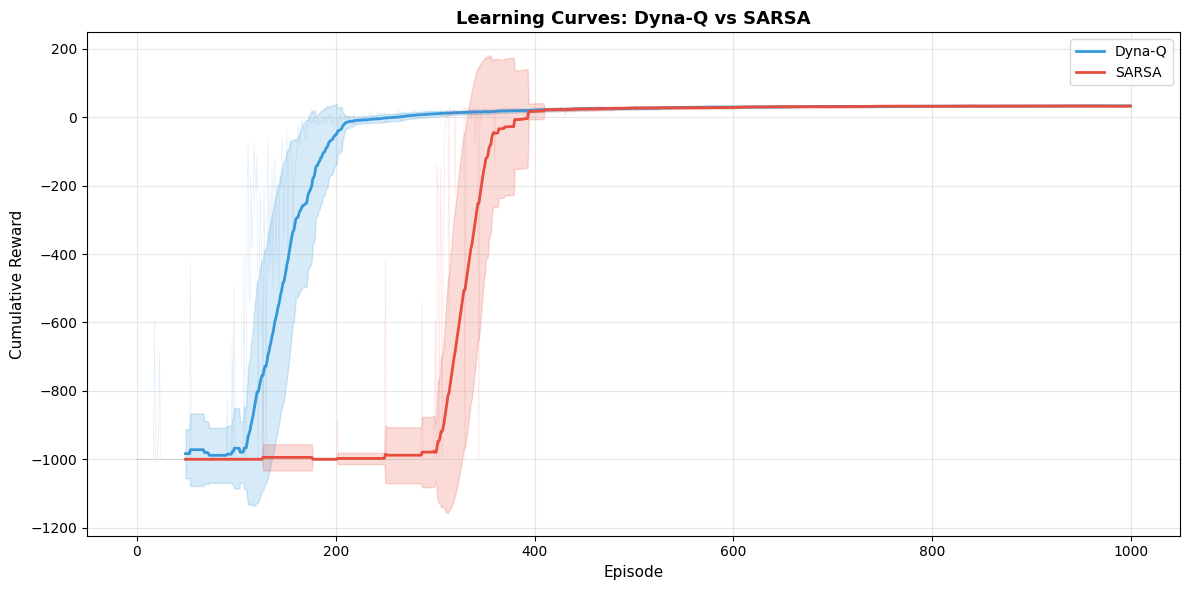

In [5]:
fig = plot_comparison_learning_curves(comparison, window=50)
plt.show()

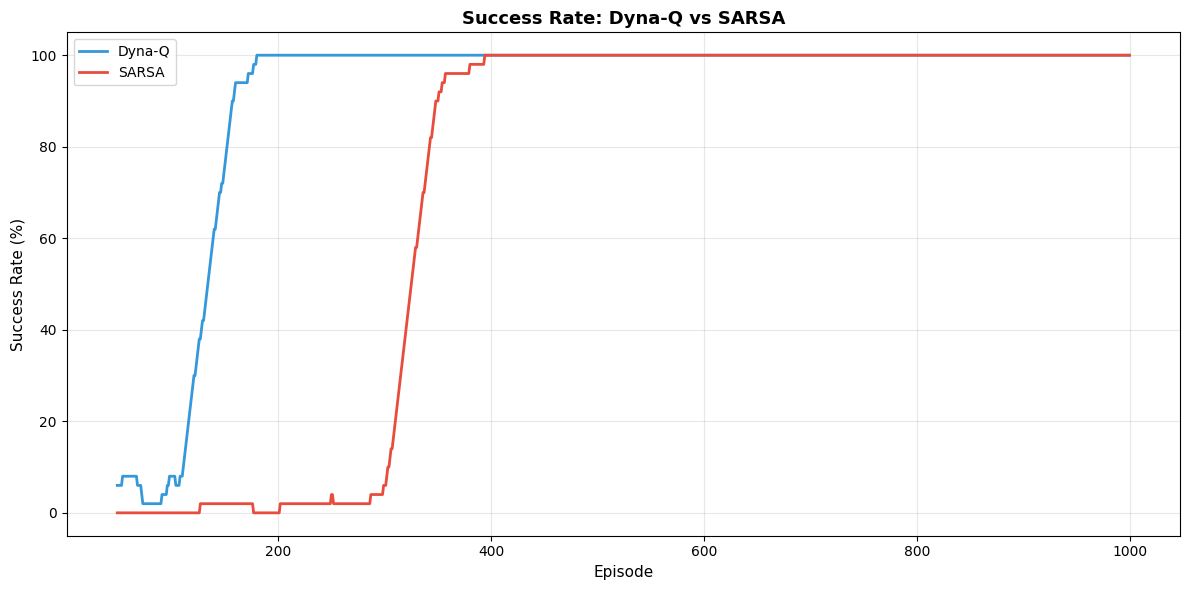

In [6]:
fig = plot_comparison_success_rates(comparison, window=50)
plt.show()

## 5. Convergence Analysis

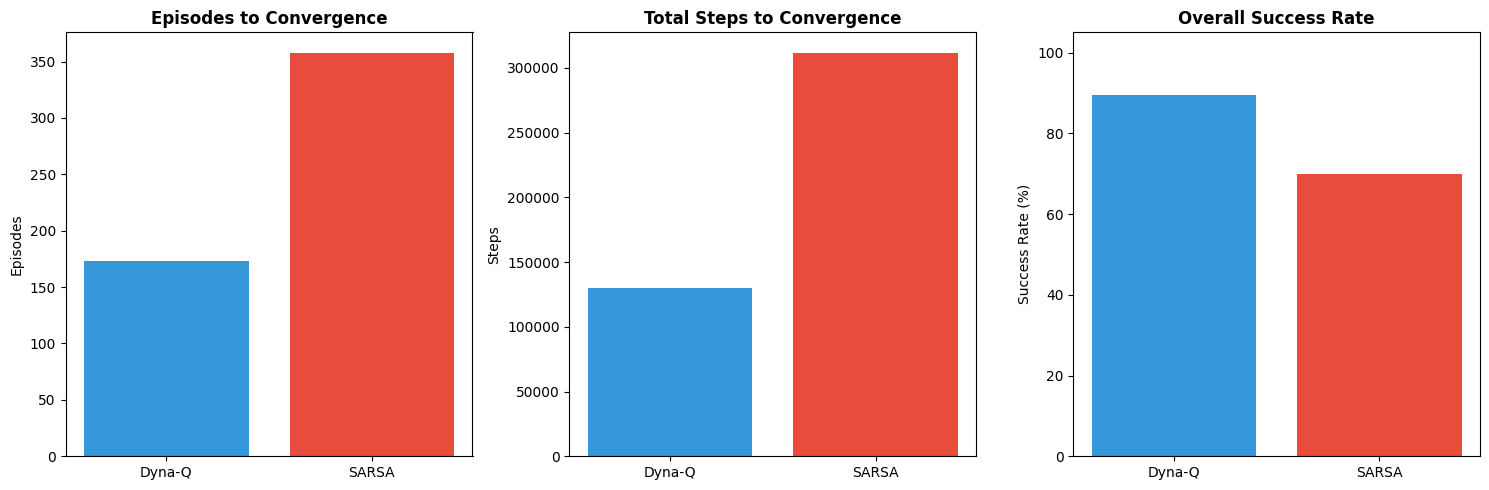

In [7]:
fig = plot_convergence_bar_chart(comparison)
plt.show()

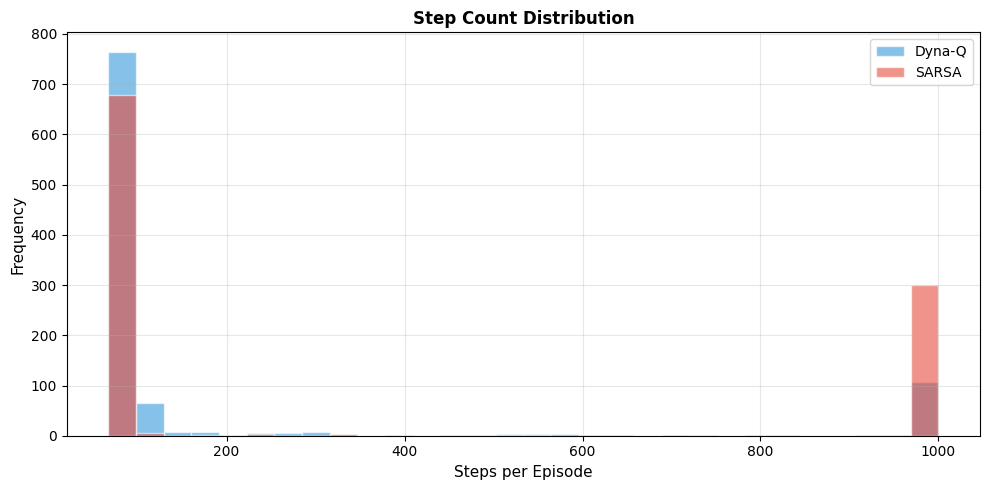

In [8]:
fig = plot_step_distribution(comparison)
plt.show()

## 6. Exploration Behavior

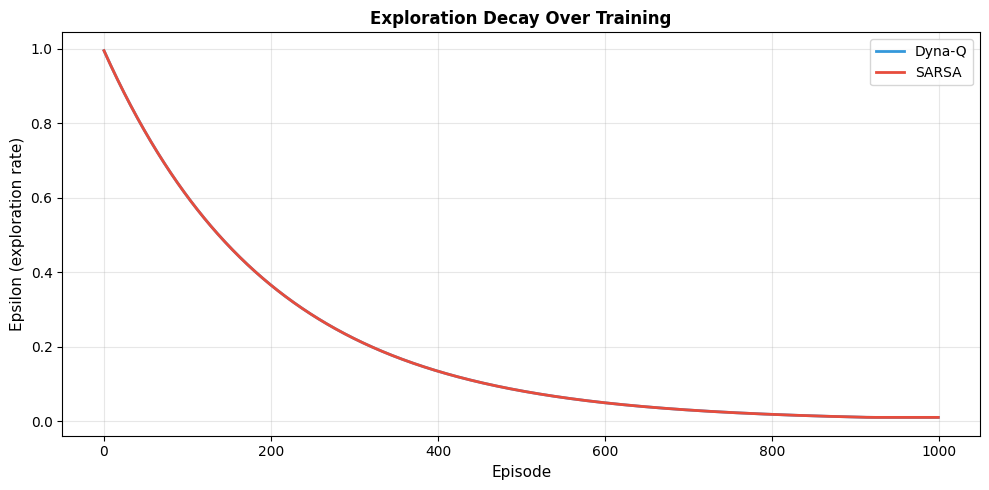

In [9]:
fig = plot_epsilon_decay(comparison)
plt.show()

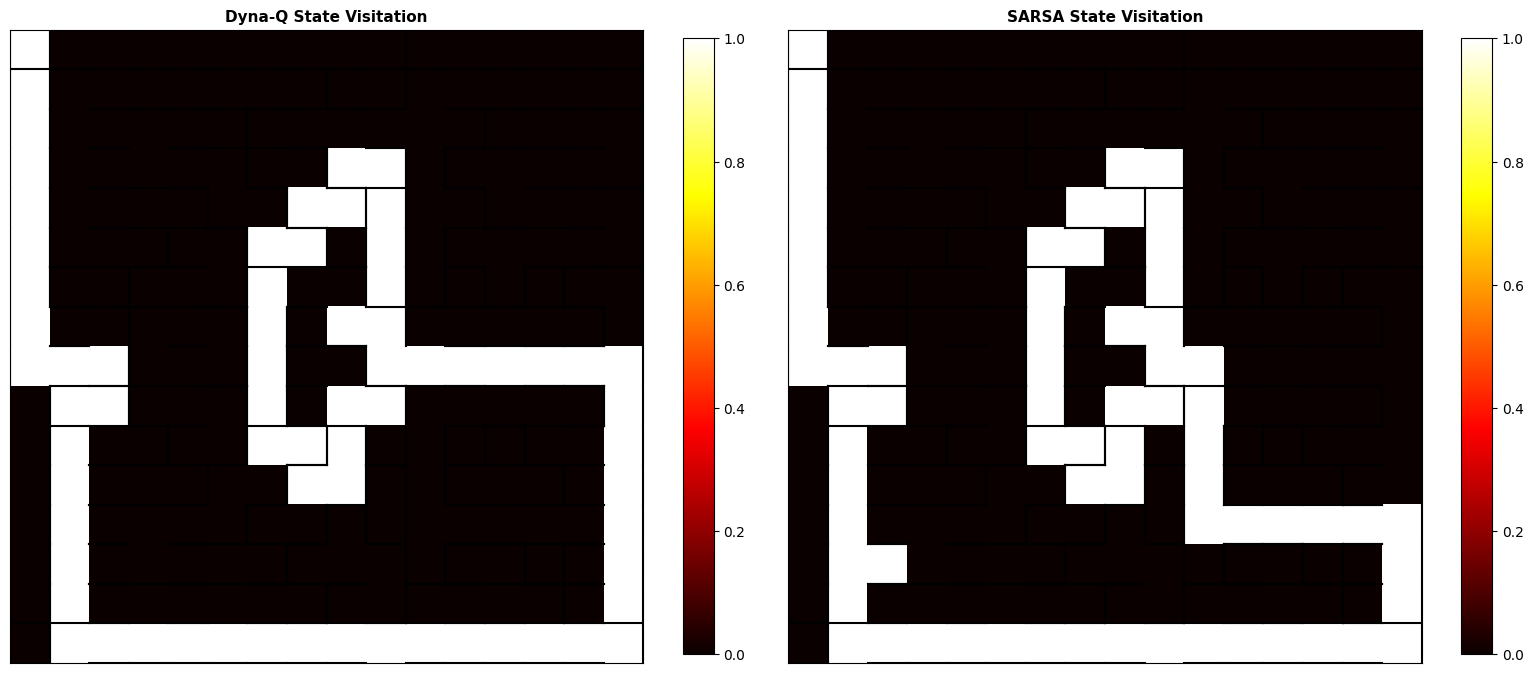

In [10]:
fig = render_heatmap_comparison(
    dq_env.get_visit_counts(),
    ss_env.get_visit_counts(),
    title_left='Dyna-Q State Visitation',
    title_right='SARSA State Visitation',
    cmap='hot',
    maze=maze,
)
plt.show()

## 7. Optimal Paths Comparison

Dyna-Q path: 68 steps
SARSA path: 68 steps


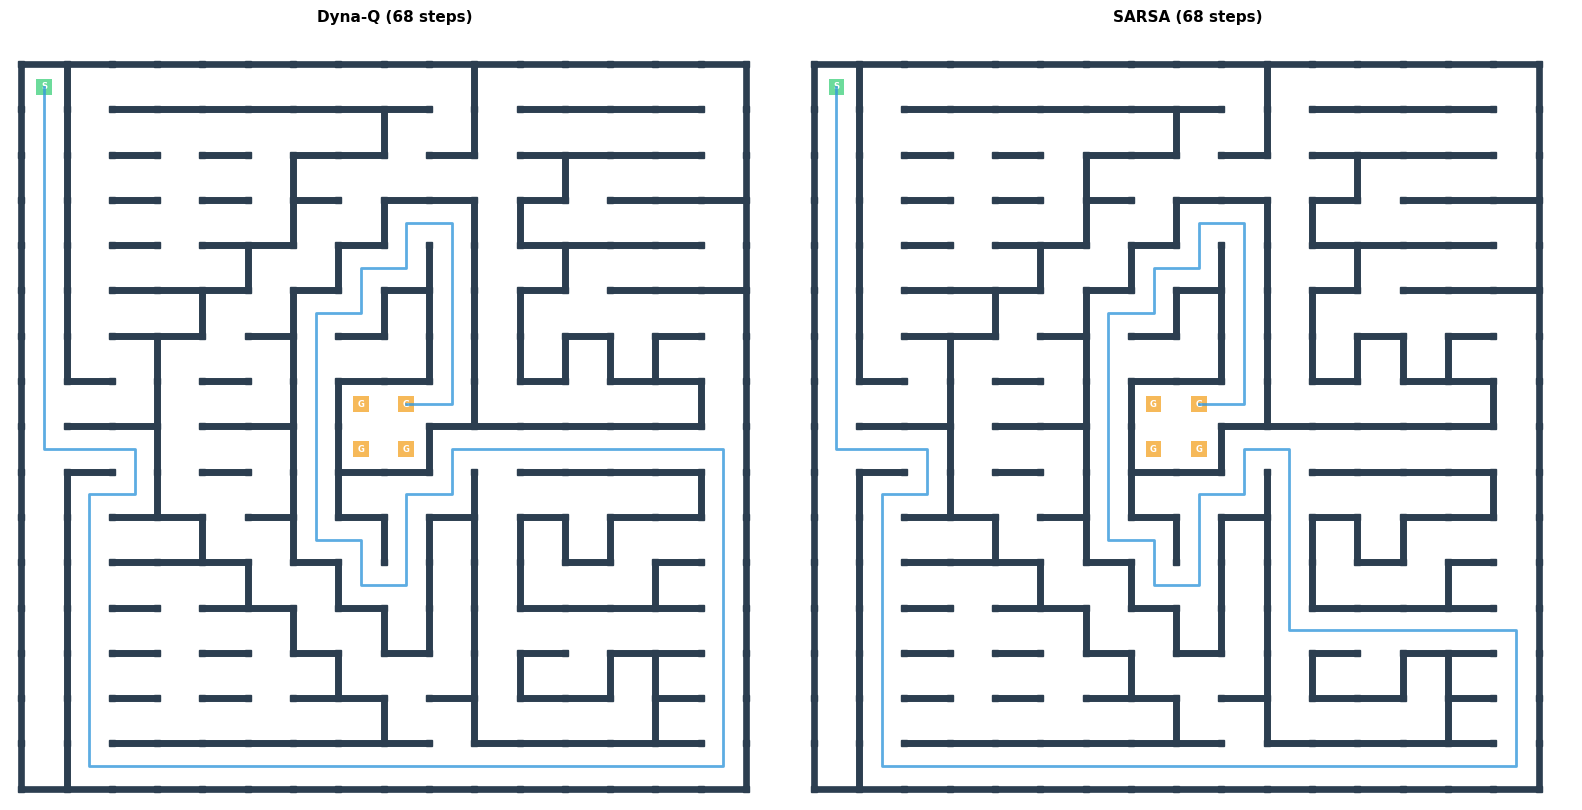

In [11]:
dq_path = extract_optimal_path(dq_agent, MicromouseEnv(maze))
ss_path = extract_optimal_path(ss_agent, MicromouseEnv(maze))

print(f'Dyna-Q path: {len(dq_path)} steps')
print(f'SARSA path: {len(ss_path)} steps')

fig = render_maze_comparison(
    maze,
    path_left=dq_path,
    path_right=ss_path,
    title_left=f'Dyna-Q ({len(dq_path)} steps)',
    title_right=f'SARSA ({len(ss_path)} steps)',
)
plt.show()

## 8. Q-Value Analysis

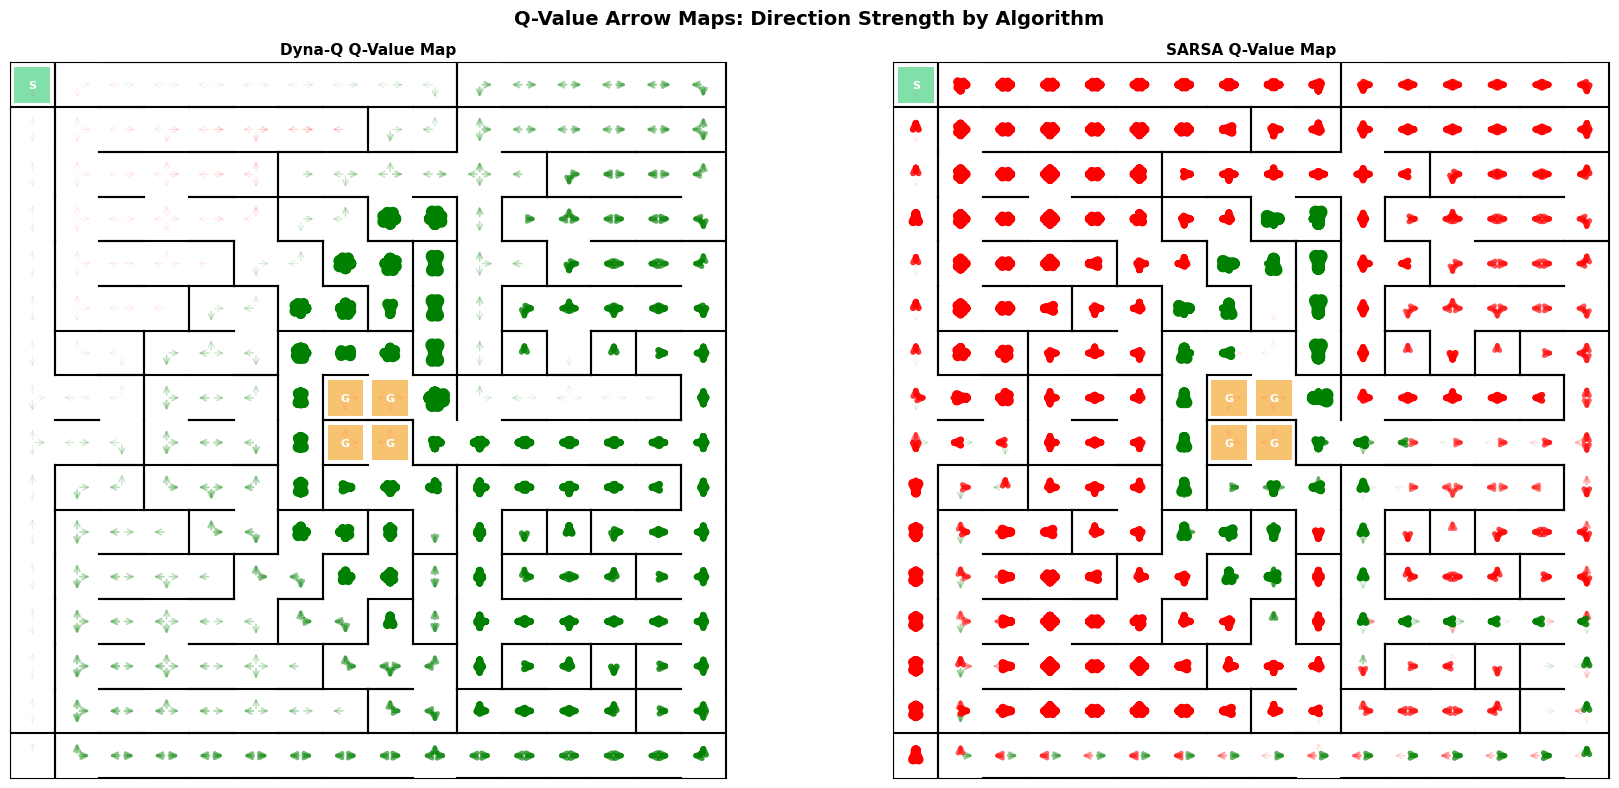

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
render_q_value_map(dq_agent.q_table, maze, ax=axes[0], title='Dyna-Q Q-Value Map')
render_q_value_map(ss_agent.q_table, maze, ax=axes[1], title='SARSA Q-Value Map')
plt.suptitle('Q-Value Arrow Maps: Direction Strength by Algorithm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

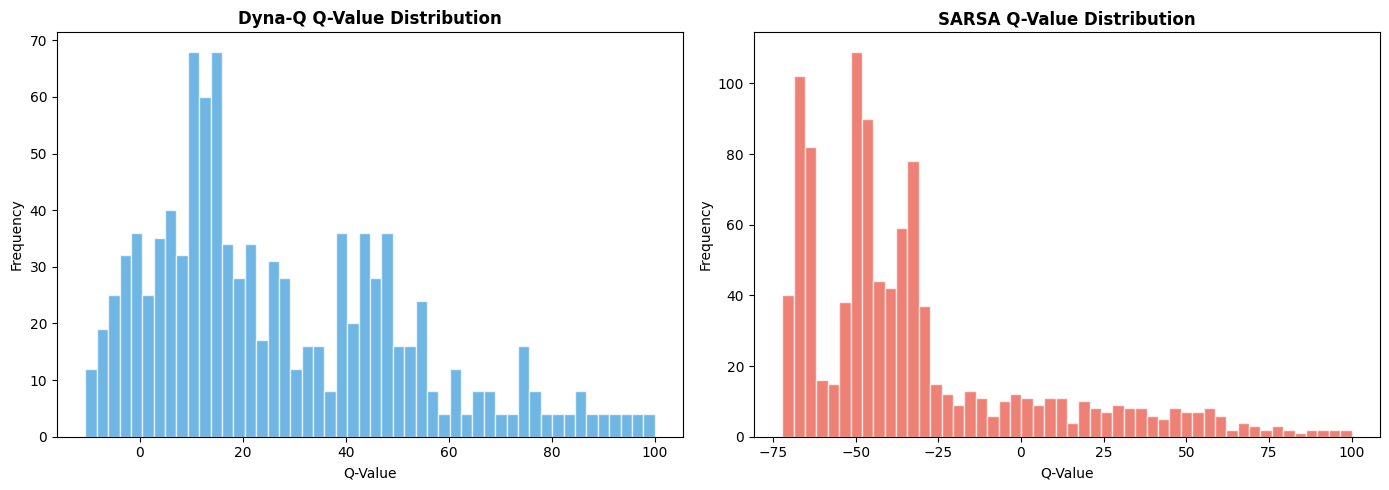

In [13]:
fig = plot_q_value_distribution(dq_agent.q_table, ss_agent.q_table)
plt.show()

## 9. Performance Radar Chart

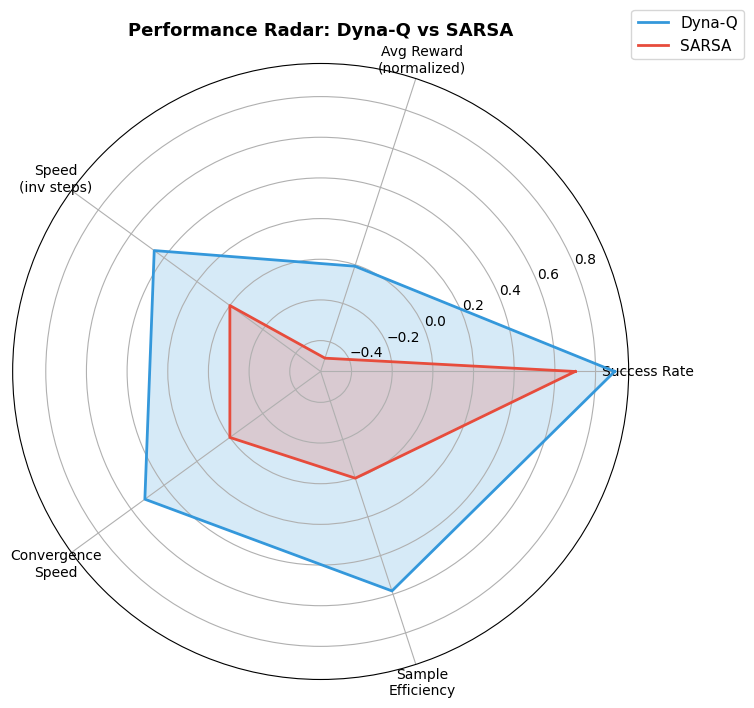

In [14]:
fig = plot_radar_comparison(comparison)
plt.show()

## 10. Statistical Significance Tests

In [15]:
reward_test = comparison.statistical_test('rewards')
steps_test = comparison.statistical_test('steps')

print('Statistical Test Results')
print('=' * 65)
for test in [reward_test, steps_test]:
    print(f"\nMetric: {test['metric']}")
    print(f"  Dyna-Q mean: {test['dyna_q_mean']:.4f} +/- {test['dyna_q_std']:.4f}")
    print(f"  SARSA mean:  {test['sarsa_mean']:.4f} +/- {test['sarsa_std']:.4f}")
    print(f"  t-statistic: {test['t_statistic']:.4f}")
    print(f"  t p-value:   {test['t_p_value']:.6f}")
    print(f"  U-statistic: {test['u_statistic']:.4f}")
    print(f"  U p-value:   {test['u_p_value']:.6f}")
    print(f"  Significant at alpha=0.05: {test['significant_at_005']}")

Statistical Test Results

Metric: rewards
  Dyna-Q mean: -102.8730 +/- 321.6582
  SARSA mean:  -286.9050 +/- 471.3601
  t-statistic: 10.1931
  t p-value:   0.000000
  U-statistic: 540951.5000
  U p-value:   0.001408
  Significant at alpha=0.05: True

Metric: steps
  Dyna-Q mean: 193.1670 +/- 291.9270
  SARSA mean:  357.6050 +/- 425.5690
  t-statistic: -10.0710
  t p-value:   0.000000
  U-statistic: 459048.5000
  U p-value:   0.001408
  Significant at alpha=0.05: True


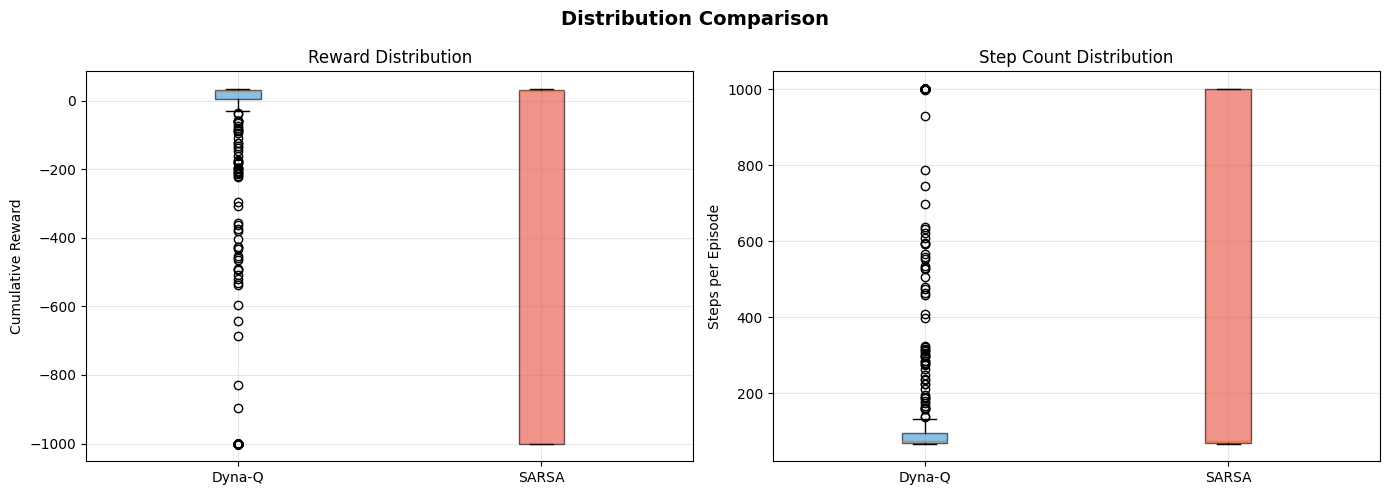

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp1 = axes[0].boxplot([dq_metrics.rewards, ss_metrics.rewards],
                tick_labels=['Dyna-Q', 'SARSA'],
                patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel('Cumulative Reward')
axes[0].set_title('Reward Distribution')
axes[0].grid(True, alpha=0.3)

bp2 = axes[1].boxplot([dq_metrics.steps, ss_metrics.steps],
                tick_labels=['Dyna-Q', 'SARSA'],
                patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('Steps per Episode')
axes[1].set_title('Step Count Distribution')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Distribution Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Multi-Seed Evaluation (Statistical Rigor)

In [17]:
n_seeds = 5
seeds = list(range(42, 42 + n_seeds))

dq_all_rewards = []
ss_all_rewards = []
dq_all_steps = []
ss_all_steps = []
dq_convergence = []
ss_convergence = []

for s in seeds:
    dq_a = DynaQAgent(n_planning_steps=n_planning_steps,
                      epsilon=epsilon_start, epsilon_decay=epsilon_decay)
    dq_e = MicromouseEnv(maze)
    dq_m, dq_snaps, dq_traj, dq_exp = train_with_snapshots(dq_a, dq_e, n_episodes=n_episodes, max_steps=max_steps,
                       alpha=alpha, gamma=gamma, seed=s,
                       agent_name='Dyna-Q', maze_name=maze.name)
    dq_all_rewards.append(dq_m.rewards)
    dq_all_steps.append(dq_m.steps)
    conv = dq_m.episodes_to_convergence()
    if conv: dq_convergence.append(conv)

    ss_a = SarsaAgent(epsilon=epsilon_start, epsilon_decay=epsilon_decay)
    ss_e = MicromouseEnv(maze)
    ss_m, ss_snaps, ss_traj, ss_exp = train_with_snapshots(ss_a, ss_e, n_episodes=n_episodes, max_steps=max_steps,
                       alpha=alpha, gamma=gamma, seed=s,
                       agent_name='SARSA', maze_name=maze.name)
    ss_all_rewards.append(ss_m.rewards)
    ss_all_steps.append(ss_m.steps)
    conv = ss_m.episodes_to_convergence()
    if conv: ss_convergence.append(conv)

dq_all_rewards = np.array(dq_all_rewards)
ss_all_rewards = np.array(ss_all_rewards)
dq_all_steps = np.array(dq_all_steps)
ss_all_steps = np.array(ss_all_steps)

print(f'Completed {n_seeds} seeds.')
print(f'Dyna-Q convergence episodes: {dq_convergence or "N/A"}')
print(f'SARSA convergence episodes: {ss_convergence or "N/A"}')

Completed 5 seeds.
Dyna-Q convergence episodes: [332, 198, 153, 199, 150]
SARSA convergence episodes: [386, 357, 330, 361, 343]


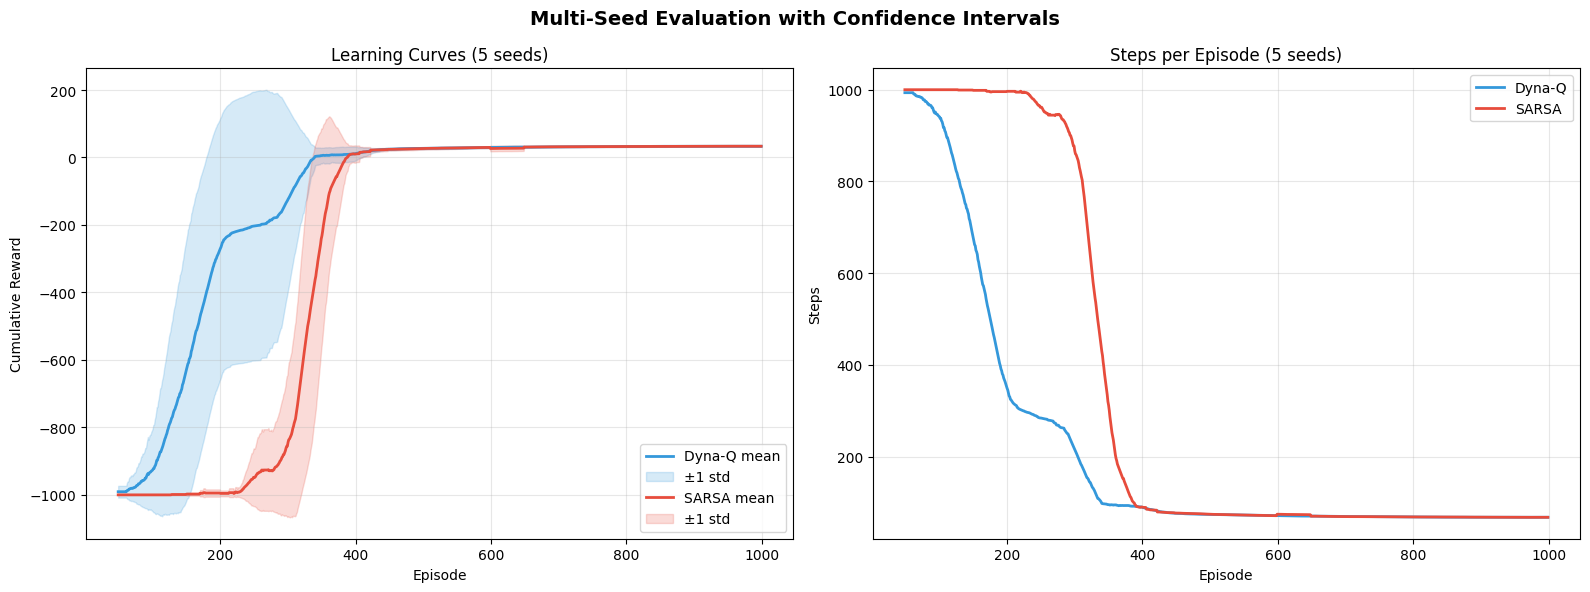

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
window = 50
episodes = np.arange(n_episodes)

# Dyna-Q with confidence interval
dq_mean = dq_all_rewards.mean(axis=0)
dq_std = dq_all_rewards.std(axis=0)
dq_smooth = np.convolve(dq_mean, np.ones(window)/window, mode='valid')
dq_std_smooth = np.convolve(dq_std, np.ones(window)/window, mode='valid')
smooth_ep = episodes[window-1:]

axes[0].plot(smooth_ep, dq_smooth, color='#3498db', linewidth=2, label='Dyna-Q mean')
axes[0].fill_between(smooth_ep,
                     dq_smooth - dq_std_smooth,
                     dq_smooth + dq_std_smooth,
                     alpha=0.2, color='#3498db', label='\u00b11 std')

ss_mean = ss_all_rewards.mean(axis=0)
ss_std = ss_all_rewards.std(axis=0)
ss_smooth = np.convolve(ss_mean, np.ones(window)/window, mode='valid')
ss_std_smooth = np.convolve(ss_std, np.ones(window)/window, mode='valid')

axes[0].plot(smooth_ep, ss_smooth, color='#e74c3c', linewidth=2, label='SARSA mean')
axes[0].fill_between(smooth_ep,
                     ss_smooth - ss_std_smooth,
                     ss_smooth + ss_std_smooth,
                     alpha=0.2, color='#e74c3c', label='\u00b11 std')

axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Cumulative Reward')
axes[0].set_title(f'Learning Curves ({n_seeds} seeds)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Steps comparison
dq_steps_mean = dq_all_steps.mean(axis=0)
ss_steps_mean = ss_all_steps.mean(axis=0)
dq_steps_smooth = np.convolve(dq_steps_mean, np.ones(window)/window, mode='valid')
ss_steps_smooth = np.convolve(ss_steps_mean, np.ones(window)/window, mode='valid')

axes[1].plot(smooth_ep, dq_steps_smooth, color='#3498db', linewidth=2, label='Dyna-Q')
axes[1].plot(smooth_ep, ss_steps_smooth, color='#e74c3c', linewidth=2, label='SARSA')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')
axes[1].set_title(f'Steps per Episode ({n_seeds} seeds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Multi-Seed Evaluation with Confidence Intervals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Comprehensive Evaluation Dashboard

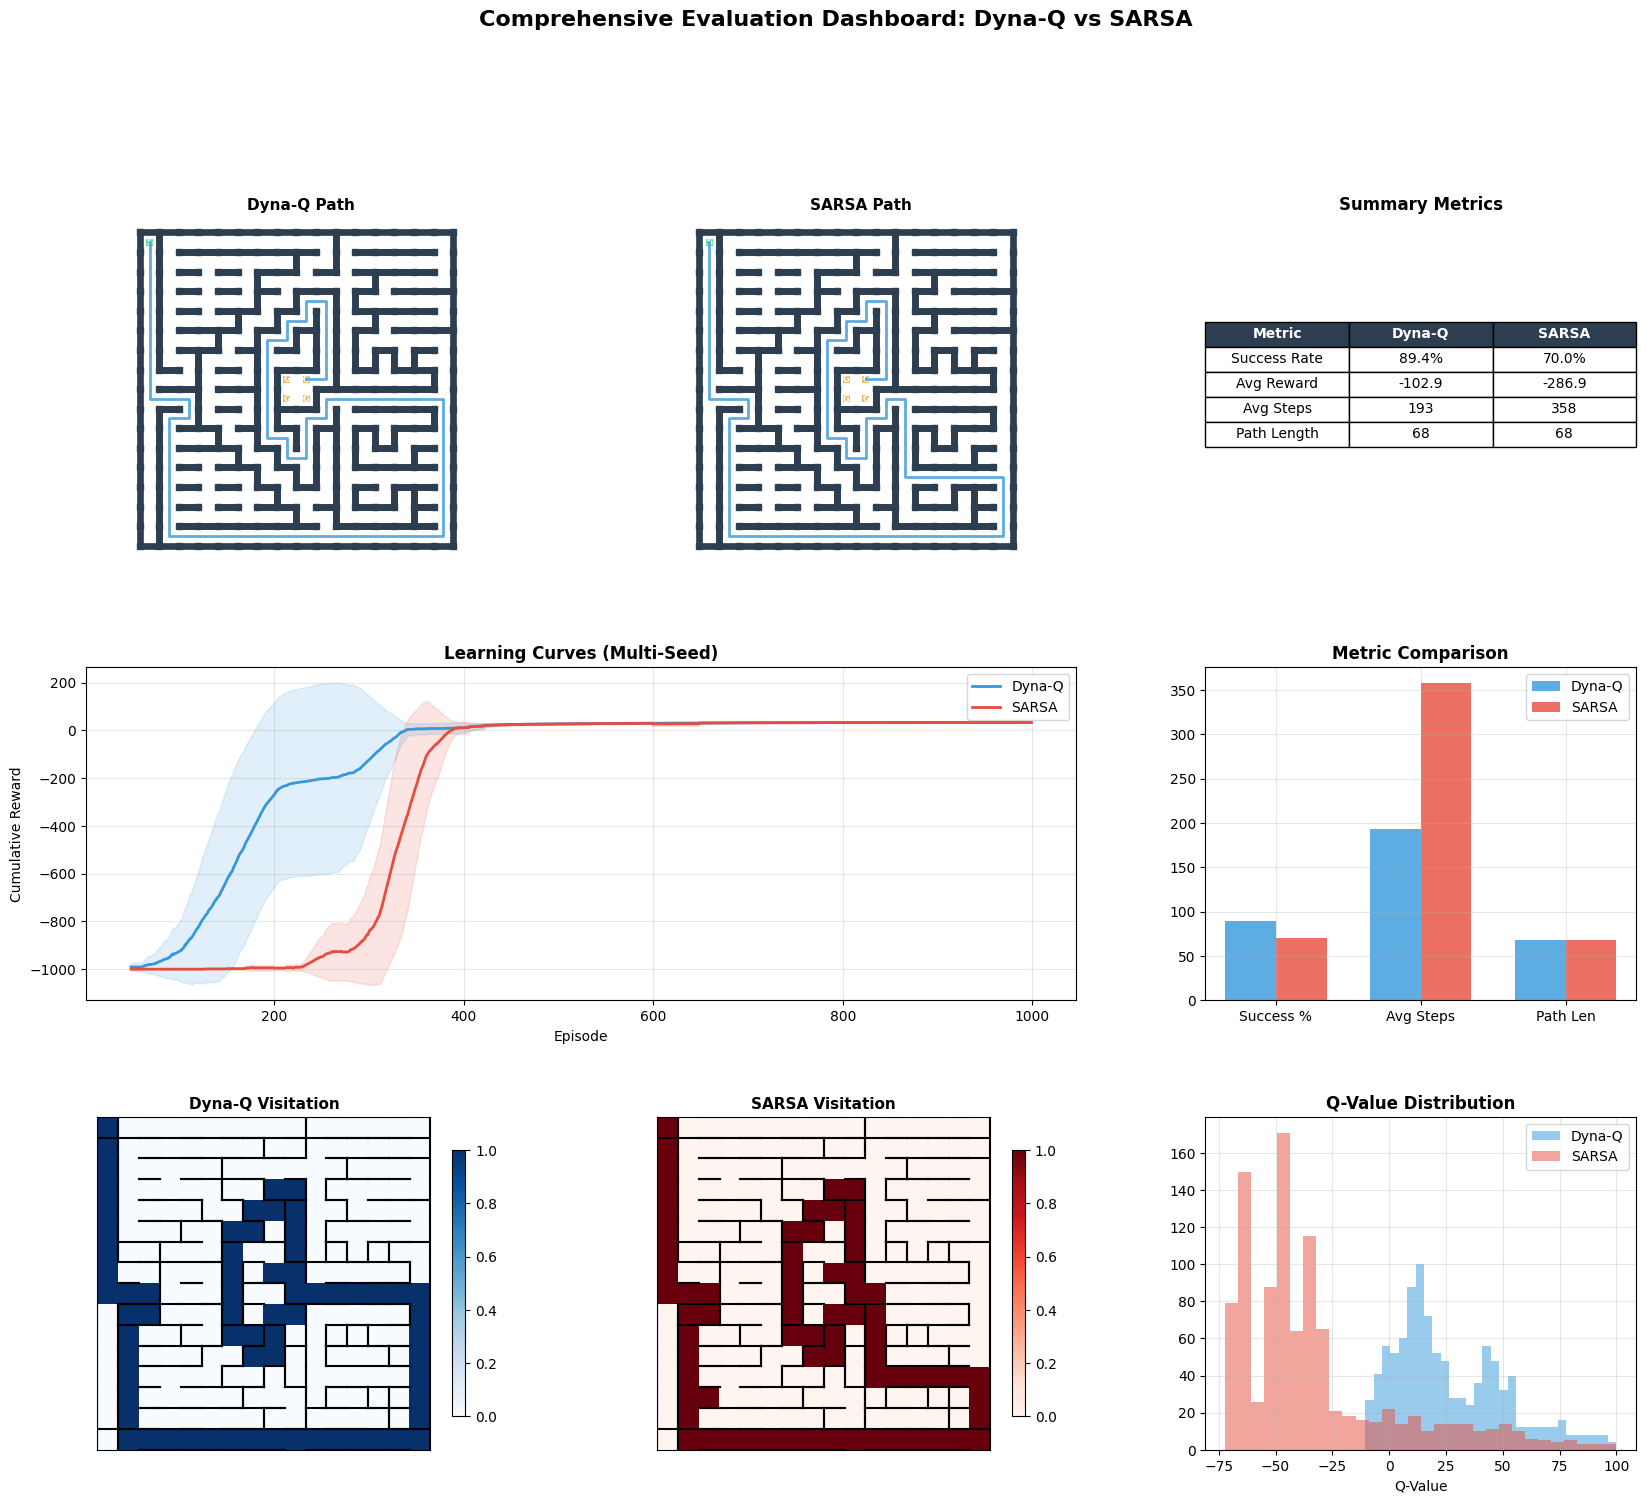

In [19]:
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# (0,0) Maze with Dyna-Q path
ax1 = fig.add_subplot(gs[0, 0])
render_maze(maze, ax=ax1, title='Dyna-Q Path', path=dq_path)

# (0,1) Maze with SARSA path
ax2 = fig.add_subplot(gs[0, 1])
render_maze(maze, ax=ax2, title='SARSA Path', path=ss_path)

# (0,2) Summary metrics
ax3 = fig.add_subplot(gs[0, 2])
metrics_data = [
    ['Metric', 'Dyna-Q', 'SARSA'],
    ['Success Rate', f"{dq_summary['success_rate']:.1%}", f"{ss_summary['success_rate']:.1%}"],
    ['Avg Reward', f"{dq_summary['mean_reward']:.1f}", f"{ss_summary['mean_reward']:.1f}"],
    ['Avg Steps', f"{dq_summary['mean_steps']:.0f}", f"{ss_summary['mean_steps']:.0f}"],
    ['Path Length', str(len(dq_path)), str(len(ss_path))],
]
ax3.axis('off')
table = ax3.table(cellText=metrics_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
ax3.set_title('Summary Metrics', fontweight='bold')

# (1,0-1) Learning curves
ax4 = fig.add_subplot(gs[1, :2])
ax4.plot(smooth_ep, dq_smooth, color='#3498db', linewidth=2, label='Dyna-Q')
ax4.fill_between(smooth_ep, dq_smooth - dq_std_smooth, dq_smooth + dq_std_smooth,
                 alpha=0.15, color='#3498db')
ax4.plot(smooth_ep, ss_smooth, color='#e74c3c', linewidth=2, label='SARSA')
ax4.fill_between(smooth_ep, ss_smooth - ss_std_smooth, ss_smooth + ss_std_smooth,
                 alpha=0.15, color='#e74c3c')
ax4.set_xlabel('Episode')
ax4.set_ylabel('Cumulative Reward')
ax4.set_title('Learning Curves (Multi-Seed)', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# (1,2) Bar chart
ax5 = fig.add_subplot(gs[1, 2])
x = np.arange(3)
width = 0.35
ax5.bar(x - width/2, [dq_summary['success_rate']*100, dq_summary['mean_steps'], len(dq_path)],
        width, label='Dyna-Q', color='#3498db', alpha=0.8)
ax5.bar(x + width/2, [ss_summary['success_rate']*100, ss_summary['mean_steps'], len(ss_path)],
        width, label='SARSA', color='#e74c3c', alpha=0.8)
ax5.set_xticks(x)
ax5.set_xticklabels(['Success %', 'Avg Steps', 'Path Len'])
ax5.set_title('Metric Comparison', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# (2,0) Dyna-Q heatmap
ax6 = fig.add_subplot(gs[2, 0])
render_heatmap(dq_env.get_visit_counts(), ax=ax6, title='Dyna-Q Visitation', cmap='Blues', maze=maze)

# (2,1) SARSA heatmap
ax7 = fig.add_subplot(gs[2, 1])
render_heatmap(ss_env.get_visit_counts(), ax=ax7, title='SARSA Visitation', cmap='Reds', maze=maze)

# (2,2) Q-value distributions
ax8 = fig.add_subplot(gs[2, 2])
dq_qv = dq_agent.q_table[dq_agent.q_table != 0]
ss_qv = ss_agent.q_table[ss_agent.q_table != 0]
if len(dq_qv) > 0:
    ax8.hist(dq_qv, bins=30, alpha=0.5, color='#3498db', label='Dyna-Q')
if len(ss_qv) > 0:
    ax8.hist(ss_qv, bins=30, alpha=0.5, color='#e74c3c', label='SARSA')
ax8.set_xlabel('Q-Value')
ax8.set_title('Q-Value Distribution', fontweight='bold')
ax8.legend()
ax8.grid(True, alpha=0.3)

fig.suptitle('Comprehensive Evaluation Dashboard: Dyna-Q vs SARSA',
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

## 13. Dynamic Comparison Animation

In [20]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

max_len = max(len(dq_path), len(ss_path))
if max_len > 1:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    def animate(frame):
        ax1.clear()
        ax2.clear()
        dq_idx = min(frame, len(dq_path) - 1)
        ss_idx = min(frame, len(ss_path) - 1)
        render_maze(maze, ax=ax1,
                   title=f'Dyna-Q (step {dq_idx+1}/{len(dq_path)})',
                   path=dq_path[:dq_idx+1], agent_pos=dq_path[dq_idx])
        render_maze(maze, ax=ax2,
                   title=f'SARSA (step {ss_idx+1}/{len(ss_path)})',
                   path=ss_path[:ss_idx+1], agent_pos=ss_path[ss_idx])

    anim = FuncAnimation(fig, animate, frames=max_len, interval=250, repeat=True)
    plt.close()
    display(HTML(anim.to_jshtml()))
else:
    print('Paths too short for animation.')